# 🌱 Phase 1: Data Governance & ETL Pipeline
**Agritech Decision Intelligence: Lettuce Yield Optimization**

> **🇬🇧 EN:** In this phase, we architect an MLOps-ready Data Governance pipeline. We implement John Tukey's Exploratory Data Analysis (EDA) principles to establish biological baselines, dynamically handle missing values via a statistical rule engine, and quarantine impossible physical anomalies before exporting a pristine artifact for predictive modeling.
>
> **🇲🇽 ES:** En esta fase, diseñamos un pipeline de Gobernanza de Datos listo para MLOps. Implementamos los principios de EDA de John Tukey para establecer líneas base biológicas, manejamos dinámicamente los valores nulos mediante un motor de reglas estadísticas y ponemos en cuarentena anomalías físicas imposibles antes de exportar un artefacto prístino para el modelado predictivo.


In [2]:
# 1. Imports, Environment & MLOps Logging Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Configure MLOps Logger
log_dir = '../logs/'
os.makedirs(log_dir, exist_ok=True)

logging.basicConfig(
    filename=os.path.join(log_dir, 'etl_pipeline.log'),
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

logging.info("--- Phase 1: Data Governance ETL Pipeline Initialized ---")
print("✅ Libraries loaded. Automated Logging System active (tracking to /logs/etl_pipeline.log).")

✅ Libraries loaded. Automated Logging System active (tracking to /logs/etl_pipeline.log).


## 📥 1. Ingestion & Exploratory Data Analysis (EDA)
**🇬🇧 EN:** We ingest the raw sensor data and extract descriptive statistics. By comparing empirical percentiles against theoretical biological optimums, we identify severe right-skewness in sensors, indicating hardware failures rather than biological variance.
**🇲🇽 ES:** Ingerimos los datos crudos de los sensores y extraemos estadística descriptiva. Al comparar los percentiles empíricos contra los óptimos biológicos teóricos, identificamos una severa asimetría positiva en los sensores, indicando fallos de hardware en lugar de varianza biológica.

In [4]:
# Load dataset
file_path = '../data/raw/lettuce_growth_complex.csv'
try:
    df_raw = pd.read_csv(file_path)
    logging.info(f"Raw dataset loaded. Shape: {df_raw.shape}")
except FileNotFoundError:
    df_raw = pd.read_csv('lettuce_growth_complex.csv')
    logging.info(f"Raw dataset loaded from root. Shape: {df_raw.shape}")

# Descriptive Statistics vs Theoretical Optimums
continuous_vars = ['Temperature_C', 'Humidity_percent', 'pH_Level', 'Nutrient_EC_mS', 'Light_Hours', 'Yield_g']
stats_summary = df_raw[continuous_vars].describe(percentiles=[.01, .25, .50, .75, .99]).T

optimal_values = {
    'Temperature_C': 20.0, 'Humidity_percent': 65.0, 'pH_Level': 6.0, 
    'Nutrient_EC_mS': 1.5, 'Light_Hours': 14.0, 'Yield_g': 'Max'
}
stats_summary['Theoretical_Optimal'] = pd.Series(optimal_values)

columns_order = ['Theoretical_Optimal', 'mean', '50%', 'std', 'min', '1%', '99%', 'max']
display(stats_summary[columns_order].round(2))

,Theoretical_Optimal,mean,50%,std,min,1%,99%,max
Temperature_C,20.0,21.03,19.98,8.66,8.93,12.86,76.40,99.82
Humidity_percent,65.0,64.97,64.90,9.86,25.80,41.45,87.60,98.80
pH_Level,6.0,6.04,6.03,1.01,0.11,3.90,8.43,13.81
Nutrient_EC_mS,1.5,1.50,1.50,0.30,0.34,0.80,2.17,2.68
Light_Hours,14.0,14.00,14.00,1.96,7.00,9.50,18.50,20.40
Yield_g,Max,158.67,149.76,101.72,50.00,50.00,353.95,403.56


## 👁️ 2. Visual Diagnostics & Missingness Topology
**🇬🇧 EN:** We utilize violin plots to visualize probability density and sensor artifacts. Furthermore, we test the missing data mechanism (MCAR) using Seaborn heatmaps and boxplots to justify our upcoming imputation strategy.
**🇲🇽 ES:** Utilizamos gráficos de violín para visualizar la densidad de probabilidad y los artefactos de los sensores. Además, probamos el mecanismo de datos faltantes (MCAR) usando mapas de calor y boxplots para justificar nuestra futura estrategia de imputación.

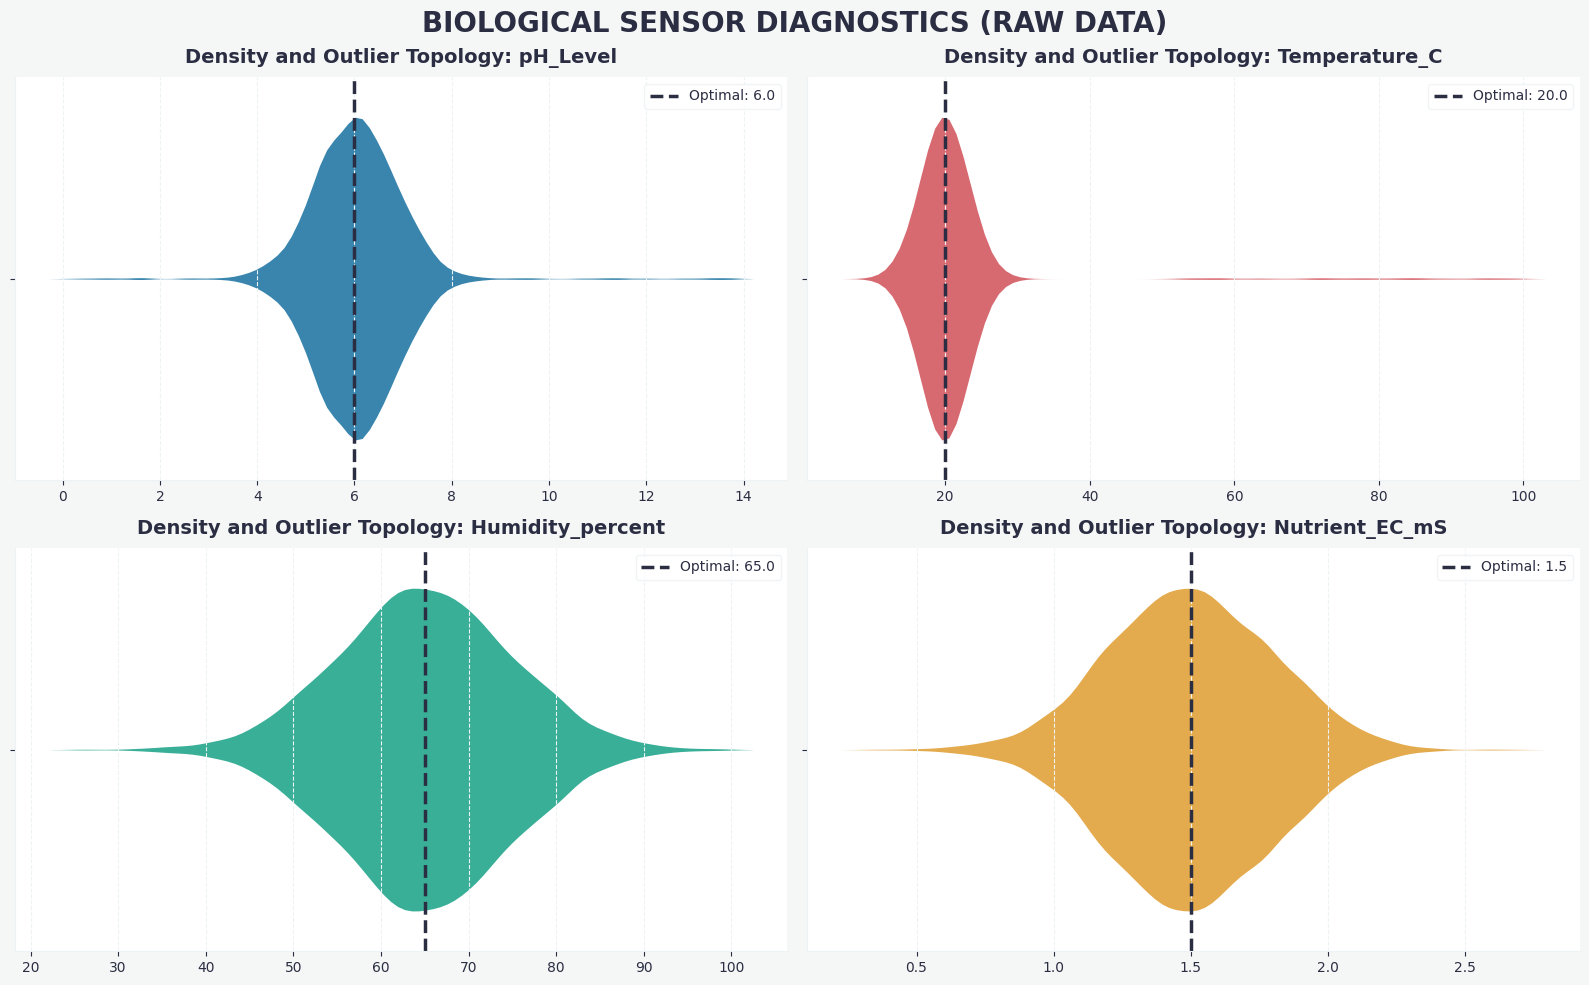

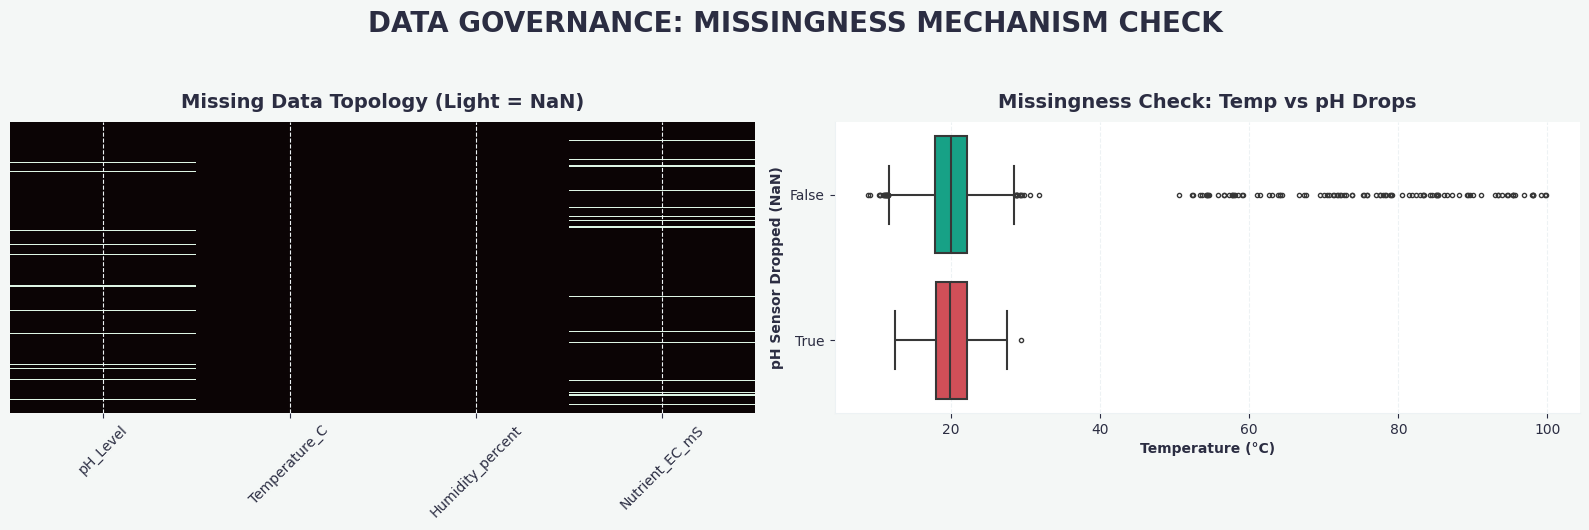

In [6]:
import os

# 1. UI Light Theme Configuration for Diagnostics
plt.style.use('default')
bg_color = '#f4f7f6'
card_color = '#ffffff'
text_color = '#2b2d42'
grid_color = '#edf2f4'
colors = ['#0077b6', '#e63946', '#00b894', '#fca311']

# Apply global parameters
plt.rcParams.update({
    'axes.facecolor': card_color, 'figure.facecolor': bg_color,
    'text.color': text_color, 'axes.labelcolor': text_color,
    'xtick.color': text_color, 'ytick.color': text_color,
    'axes.edgecolor': grid_color, 'axes.grid': True,
    'grid.color': grid_color, 'grid.linestyle': '--'
})

# Ensure the output directory exists before saving
output_dir = '../reports/figures/'
os.makedirs(output_dir, exist_ok=True)

# --- CHART 1: DISTRIBUTION DIAGNOSTICS ---
fig1, axes1 = plt.subplots(2, 2, figsize=(16, 10))
features_to_plot = ['pH_Level', 'Temperature_C', 'Humidity_percent', 'Nutrient_EC_mS']

for i, ax in enumerate(axes1.flatten()):
    feature = features_to_plot[i]
    # Violin plot with premium UI (No borders, slight transparency)
    sns.violinplot(x=df_raw[feature], ax=ax, color=colors[i], inner="box", linewidth=0, alpha=0.85)
    
    # Optimum Line
    if feature in optimal_values and optimal_values[feature] != 'Max':
        ax.axvline(optimal_values[feature], color=text_color, linestyle='--', linewidth=2.5, label=f'Optimal: {optimal_values[feature]}')
        ax.legend(frameon=True, facecolor=card_color, edgecolor=grid_color)
    
    ax.set_title(f'Density and Outlier Topology: {feature}', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['bottom', 'left']].set_color(grid_color)

plt.suptitle('BIOLOGICAL SENSOR DIAGNOSTICS (RAW DATA)', fontsize=20, fontweight='black', y=0.98)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'ui_violin_plots.png'), bbox_inches='tight', dpi=300, facecolor=bg_color)
plt.show()

# --- CHART 2: MISSINGNESS TOPOLOGY ---
df_raw['pH_is_missing'] = df_raw['pH_Level'].isnull()

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap (Using a sleek dark palette for contrast)
sns.heatmap(df_raw[['pH_Level', 'Temperature_C', 'Humidity_percent', 'Nutrient_EC_mS']].isnull(), 
            cbar=False, cmap='mako', yticklabels=False, ax=axes2[0])
axes2[0].set_title('Missing Data Topology (Light = NaN)', fontsize=14, fontweight='bold', pad=10)
axes2[0].tick_params(axis='x', rotation=45)

# Boxplot (Horizontal orientation for better UX)
sns.boxplot(y='pH_is_missing', x='Temperature_C', data=df_raw, orient='h', 
            palette=['#00b894', '#e63946'], ax=axes2[1], linewidth=1.5, fliersize=3)
axes2[1].set_title('Missingness Check: Temp vs pH Drops', fontsize=14, fontweight='bold', pad=10)
axes2[1].set_ylabel('pH Sensor Dropped (NaN)', fontweight='bold')
axes2[1].set_xlabel('Temperature (°C)', fontweight='bold')
axes2[1].spines[['top', 'right']].set_visible(False)
axes2[1].spines[['bottom', 'left']].set_color(grid_color)

plt.suptitle('DATA GOVERNANCE: MISSINGNESS MECHANISM CHECK', fontsize=20, fontweight='black', y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'ui_missingness.png'), bbox_inches='tight', dpi=300, facecolor=bg_color)
plt.show()

# Clean up temporary column and reset plot styles
df_raw.drop(columns=['pH_is_missing'], inplace=True)
plt.rcParams.update(plt.rcParamsDefault)

## 🔗 3. Bivariate Storytelling: The Non-Linear Reality
**🇬🇧 EN:** To dictate our modeling strategy for Phase 2, we must prove the non-linear biological thresholds. A polynomial regression overlay reveals exactly how lettuce yield decays when diverging from the pH 6.0 optimal zone.
**🇲🇽 ES:** Para dictar nuestra estrategia de modelado para la Fase 2, debemos probar los umbrales biológicos no lineales. Una superposición de regresión polinomial revela exactamente cómo decae el rendimiento de la lechuga al alejarse de la zona óptima de pH 6.0.

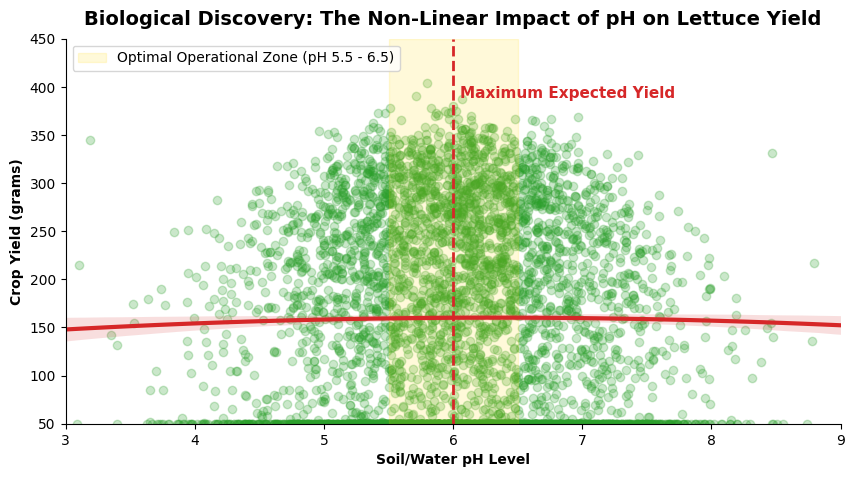

In [8]:
plt.figure(figsize=(10, 5))
sns.regplot(x='pH_Level', y='Yield_g', data=df_raw, 
            scatter_kws={'alpha': 0.25, 'color': '#2ca02c'}, 
            line_kws={'color': '#d62728', 'linewidth': 3}, order=2)

plt.axvspan(5.5, 6.5, color='gold', alpha=0.15, label='Optimal Operational Zone (pH 5.5 - 6.5)')
plt.axvline(6.0, color='#d62728', linestyle='--', linewidth=2)

plt.text(6.05, df_raw['Yield_g'].max() - 15, 'Maximum Expected Yield', fontsize=11, color='#d62728', fontweight='bold')
plt.title('Biological Discovery: The Non-Linear Impact of pH on Lettuce Yield', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Soil/Water pH Level', fontweight='bold')
plt.ylabel('Crop Yield (grams)', fontweight='bold')
plt.xlim(3, 9)
plt.ylim(50, 450)
plt.legend(loc='upper left', frameon=True)
sns.despine(trim=True)
plt.show()

## ⚙️ 4. Automated Data Governance Engine
**🇬🇧 EN:** We initialize a dynamic rule engine that eradicates duplicates, normalizes temporal formats, evaluates feature skewness to route robust imputation logic (Median vs Mean), and quarantines extreme biological outliers based on statistical thresholds.
**🇲🇽 ES:** Inicializamos un motor de reglas dinámico que erradica duplicados, normaliza formatos temporales, evalúa la asimetría para enrutar la lógica de imputación (Mediana vs Media) y aísla anomalías biológicas extremas.

In [10]:
print("--- 🛡️ Automated Data Governance Engine Initialized ---\n")

# 0. Structural Integrity
df_clean = df_raw.drop_duplicates().reset_index(drop=True)
if df_clean['Planting_Date'].astype(str).str.contains('/').any():
    df_clean['Planting_Date'] = df_clean['Planting_Date'].astype(str).str.replace('/', '-')
df_clean['Planting_Date'] = pd.to_datetime(df_clean['Planting_Date'])
logging.info("Structural fixes applied: duplicates dropped, dates standardized.")
print(">> DECISION [STRUCTURAL]: Duplicates eradicated and dates standardized.")

# 1. Dynamic Imputation Strategy
for feature in ['pH_Level', 'Nutrient_EC_mS']:
    skewness = df_clean[feature].skew()
    if abs(skewness) > 1.0:
        fill_val = df_clean[feature].median()
        strategy = "MEDIAN (Robust to skewness)"
    else:
        fill_val = df_clean[feature].mean()
        strategy = "MEAN (Normal distribution)"
    
    df_clean[feature] = df_clean[feature].fillna(fill_val)
    logging.info(f"Imputation for {feature}: Applied {strategy}. Skew: {skewness:.2f}")
    print(f">> DECISION [IMPUTATION - {feature}]: Skewness {skewness:.2f} -> Applying {strategy}")

# 2. Biological Quarantine
biological_temp_limit = 50.0
max_temp = df_clean['Temperature_C'].max()
if max_temp > biological_temp_limit:
    valid_mask = df_clean['Temperature_C'] <= biological_temp_limit
    dropped_count = len(df_clean) - valid_mask.sum()
    logging.warning(f"Quarantine active: {dropped_count} records exceeded {biological_temp_limit}°C.")
    print(f">> DECISION [QUARANTINE]: {dropped_count} extreme sensor failures isolated.")
else:
    valid_mask = pd.Series([True] * len(df_clean))
    print(">> DECISION [QUARANTINE]: No extreme temperature violations.")

df_final = df_clean[valid_mask].reset_index(drop=True)
print(f"\n✅ Engine Execution Complete. Final shape: {df_final.shape}")

--- 🛡️ Automated Data Governance Engine Initialized ---

>> DECISION [STRUCTURAL]: Duplicates eradicated and dates standardized.
>> DECISION [IMPUTATION - pH_Level]: Skewness 1.08 -> Applying MEDIAN (Robust to skewness)
>> DECISION [IMPUTATION - Nutrient_EC_mS]: Skewness -0.00 -> Applying MEAN (Normal distribution)
>> DECISION [QUARANTINE]: 100 extreme sensor failures isolated.

✅ Engine Execution Complete. Final shape: (4900, 9)


## 📈 5. Value Demonstration & Artifact Export
**🇬🇧 EN:** Visual proof of the Data Governance impact before exporting the pristine dataset.
**🇲🇽 ES:** Prueba visual del impacto de la Gobernanza de Datos antes de exportar el dataset prístino.

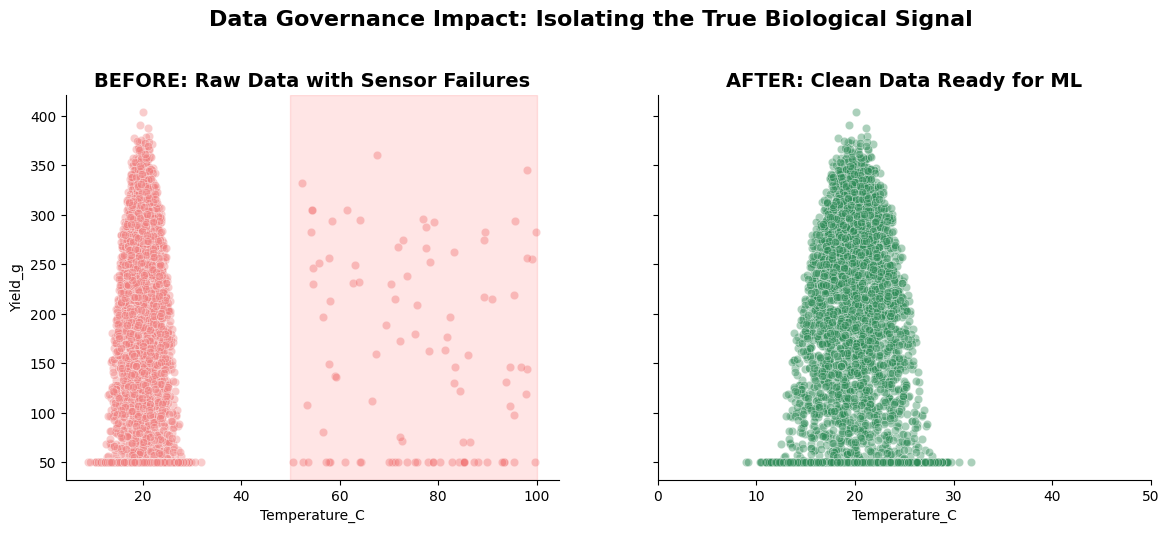

✅ Clean dataset successfully exported. Pipeline closed.


In [12]:
# Before vs After Storytelling
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.scatterplot(x='Temperature_C', y='Yield_g', data=df_raw, ax=axes[0], color='lightcoral', alpha=0.4)
axes[0].set_title('BEFORE: Raw Data with Sensor Failures', fontsize=14, fontweight='bold')
axes[0].axvspan(50, 100, color='red', alpha=0.1)

sns.scatterplot(x='Temperature_C', y='Yield_g', data=df_final, ax=axes[1], color='seagreen', alpha=0.4)
axes[1].set_title('AFTER: Clean Data Ready for ML', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 50)

plt.suptitle('Data Governance Impact: Isolating the True Biological Signal', fontsize=16, fontweight='bold', y=1.05)
sns.despine()
plt.show()

# Artifact Export
output_dir = '../data/processed/'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'lettuce_growth_clean.csv')
df_final.to_csv(output_path, index=False)

logging.info(f"ETL Complete. Clean artifact exported to {output_path}. Shape: {df_final.shape}")
print(f"✅ Clean dataset successfully exported. Pipeline closed.")

## 📬 6. Contact
**Pablo Alberto Santana Flores**
*Data Scientist | PhDc in Marine Sciences | Chemical Engineer*

* 💼 **LinkedIn:** [linkedin.com/in/pablo-santana-mx](https://www.linkedin.com/in/pablo-santana-mx)
* 🐙 **GitHub:** [github.com/Pablo-Santana-MX](https://github.com/Pablo-Santana-MX)
